1) Imports

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

2) Load cleaned dataset

In [51]:
df = pd.read_csv("../data/processed/reviews_clean.csv")
df_supervised = pd.read_csv("../data/processed/reviews_supervised.csv")

df.shape, df_supervised.shape

((34433, 11), (24104, 11))

3) Rating distribution

This distribution shows how ratings are distributed across the dataset and whether the classes are balanced.

/var/folders/h5/fthz7w1d6l1_w09sqsgml2vm0000gn/T/ipykernel_2031/172843405.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="note", data=df_supervised, palette="viridis")


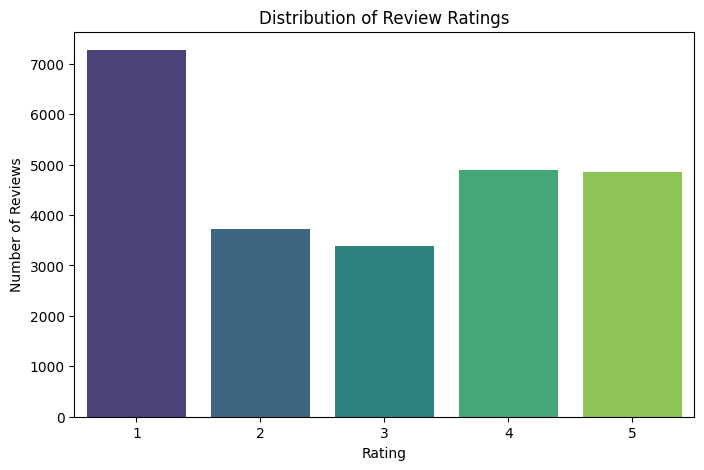

In [52]:
plt.figure(figsize=(8,5))

sns.countplot(x="note", data=df_supervised, palette="viridis")

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

The class are slighty imbalanced with a large number of 1 star review.However, all classes remains sufficiently represented. 

4) Reviews per insurance company

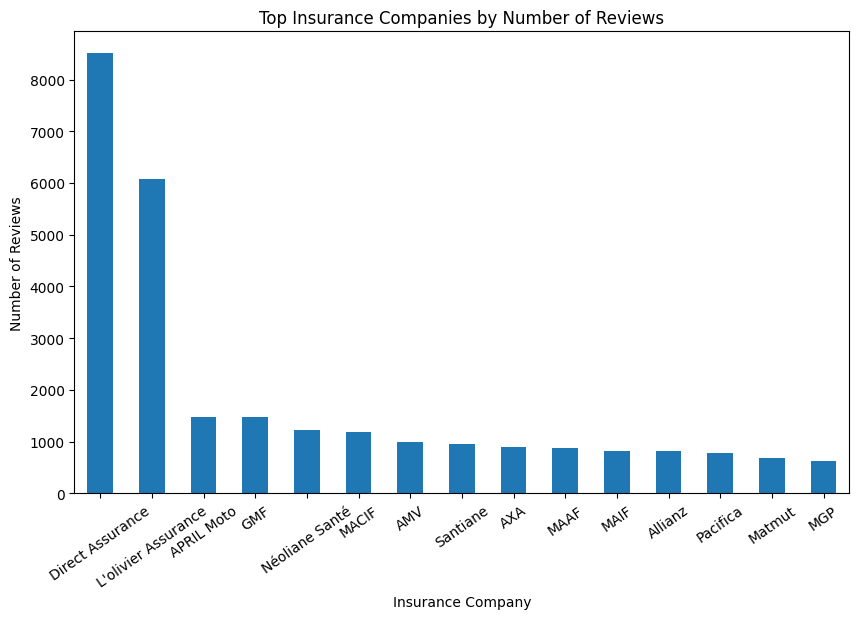

In [53]:
plt.figure(figsize=(10,6))

df["assureur"].value_counts().head(15).plot(kind="bar")

plt.title("Top Insurance Companies by Number of Reviews")
plt.xlabel("Insurance Company")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=35)

plt.show()

5) Reviews by product type

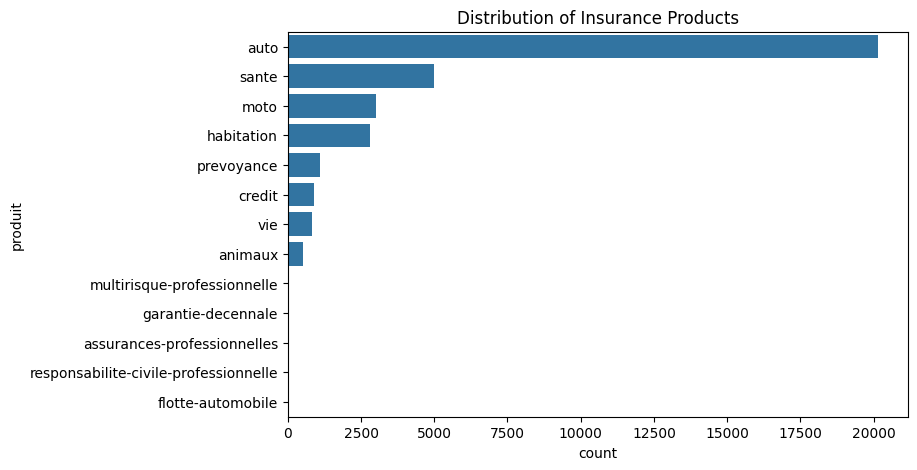

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(y="produit", data=df, order=df["produit"].value_counts().index)

plt.title("Distribution of Insurance Products")

plt.show()

6) Review lenghth analysis

In [55]:
df["review_length"] = df["avis_clean"].apply(lambda x: len(str(x).split()))

df["review_length"].describe()

count    34433.000000
mean        61.221590
std         70.502061
min          1.000000
25%         27.000000
50%         35.000000
75%         68.000000
max       1538.000000
Name: review_length, dtype: float64

- Distribution of review length

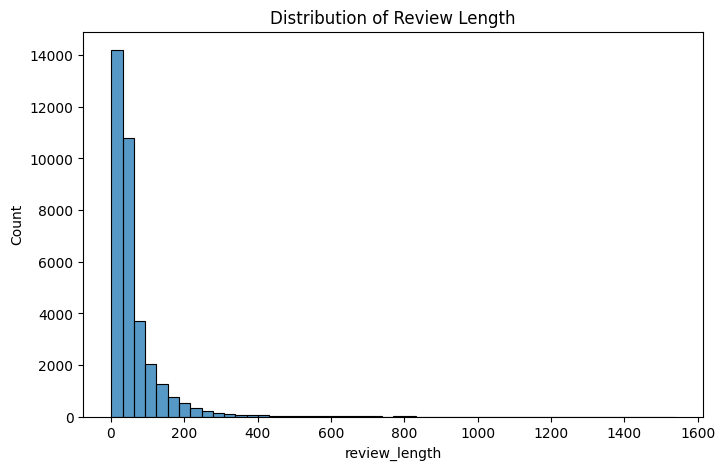

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(df["review_length"], bins=50)

plt.title("Distribution of Review Length")

plt.show()

- Average review length by rating

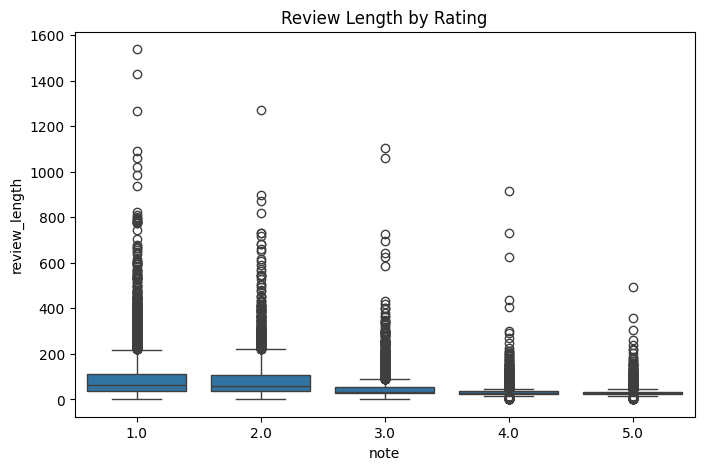

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(x= "note", y= "review_length", data=df)

plt.title("Review Length by Rating")

plt.show()

We can say that the review length has no influence on the ranking. 

7) Most frequent words

In [58]:
all_words = " ".join(df["avis_clean"]).split()

all_words = [w for w in all_words if len(w) > 4] # remove short words("ex","de","et", ec)

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

top_words

[('assurance', 17516),
 ('service', 9484),
 ('contrat', 7265),
 ('depuis', 6927),
 ('cette', 6414),
 ('satisfait', 5925),
 ('faire', 5503),
 ('sinistre', 5072),
 ('avoir', 5029),
 ('toujours', 4860),
 ('client', 4836),
 ('après', 4526),
 ('votre', 3992),
 ('véhicule', 3920),
 ('téléphone', 3713),
 ('rapide', 3599),
 ('dossier', 3577),
 ('merci', 3484),
 ('demande', 3444),
 ('alors', 3319)]

Visualization

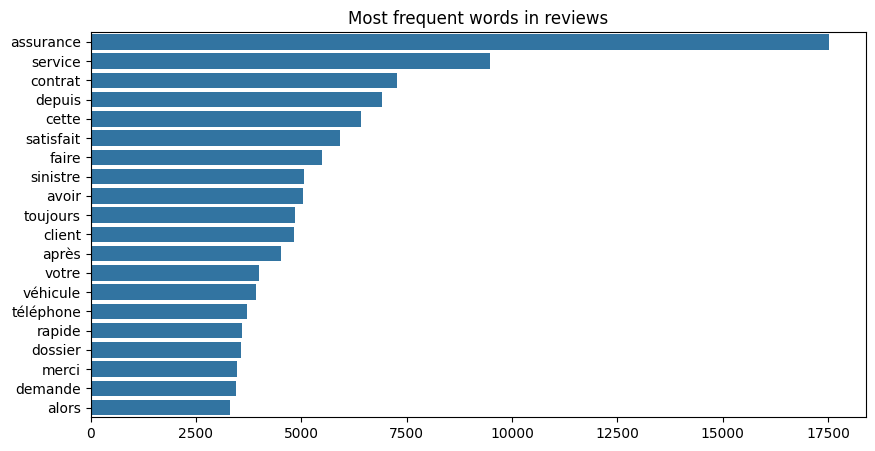

In [59]:
words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=words)

plt.title("Most frequent words in reviews")

plt.show()

- We can add a wordcloud for better visualization

Note: you may need to restart the kernel to use updated packages.


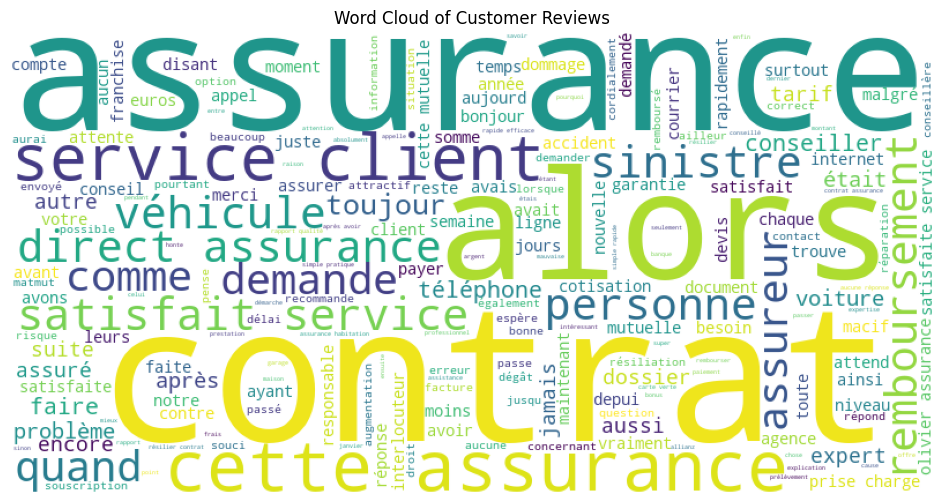

In [60]:
%pip install wordcloud

from wordcloud import WordCloud, STOPWORDS

words = " ".join(df["avis_clean"]).split()

words = [w for w in words if len(w) > 4]

text = " ".join(words)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Customer Reviews")

plt.show()

- Let's see what are the most common words for bad review

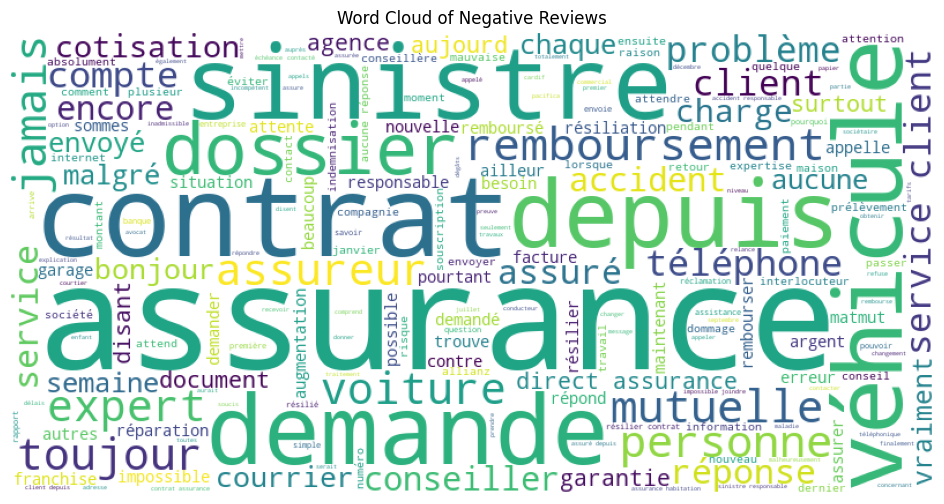

In [61]:
# select negative reviews
negative_reviews = df_supervised[df_supervised["note"] <= 2]

words = " ".join(negative_reviews["avis_clean"]).split()

# keep only words with more than 3 letters
words = [w for w in words if len(w) > 5]

text = " ".join(words)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")

plt.title("Word Cloud of Negative Reviews")

plt.show()

8) Frequent bigrams

In [62]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)

X = vectorizer.fit_transform(df["avis_clean"])

bigrams = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

bigram_counts = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)

bigram_counts[:10]

[('je suis', np.int64(11676)),
 ('de la', np.int64(7386)),
 ('que je', np.int64(5107)),
 ('je ne', np.int64(4219)),
 ('de mon', np.int64(3563)),
 ('je ai', np.int64(3319)),
 ('pas de', np.int64(3166)),
 ('du service', np.int64(3125)),
 ('suis satisfait', np.int64(2962)),
 ('qu il', np.int64(2661))]

Visualisation

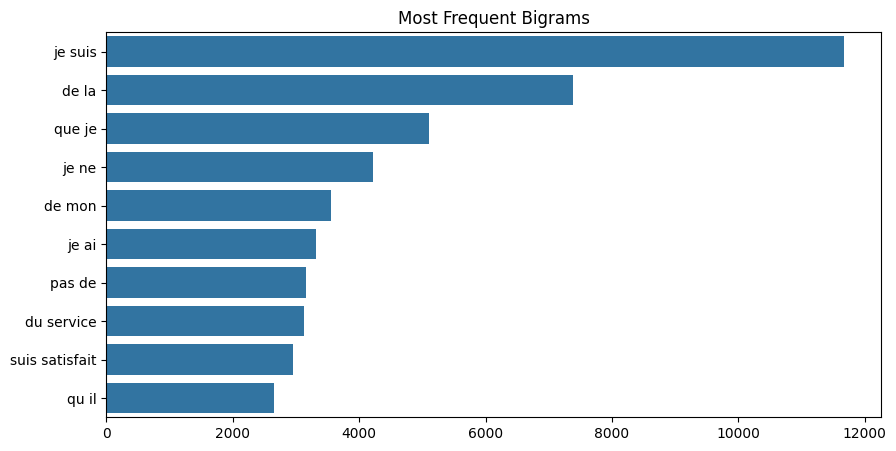

In [63]:
bigrams = [b[0] for b in bigram_counts[:10]]
counts = [b[1] for b in bigram_counts[:10]]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=bigrams)

plt.title("Most Frequent Bigrams")

plt.show()

We need more words to understand the meaning of those sentence. 

9) Frequent sentences

In [66]:
vectorizer = CountVectorizer(ngram_range=(6,6), max_features=20)

X = vectorizer.fit_transform(df["avis_clean"])

trigrams = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

trigram_counts = sorted(zip(trigrams, counts), key=lambda x: x[1], reverse=True)

trigram_counts[:10]

# I used trigrams first and then I changed to 6-grams because the most common trigrams were not very informative. That's why some variable are named trigrams but they are actually 6-grams.

[('je suis satisfait du service et', np.int64(212)),
 ('je suis satisfait du service les', np.int64(144)),
 ('suis satisfait du service les prix', np.int64(128)),
 ('je suis très satisfait du service', np.int64(98)),
 ('je suis satisfait du service le', np.int64(94)),
 ('du service les prix me conviennent', np.int64(91)),
 ('satisfait du service les prix me', np.int64(79)),
 ('je suis satisfait du prix et', np.int64(73)),
 ('je ne recommande pas du tout', np.int64(72)),
 ('suis satisfait du service le prix', np.int64(68))]

Visualisations

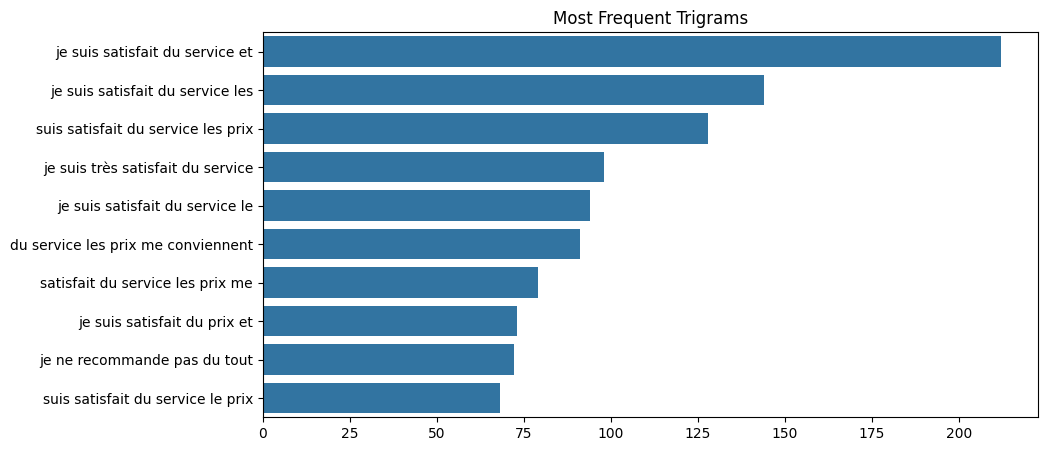

In [67]:
trigrams = [t[0] for t in trigram_counts[:10]]
counts = [t[1] for t in trigram_counts[:10]]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=trigrams)

plt.title("Most Frequent Trigrams")

plt.show()

According to the reviews, the vast majority of people are satisfied with their assurance. 